In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import cv2
from collections import Counter
from random import sample

(461, 346, 3)

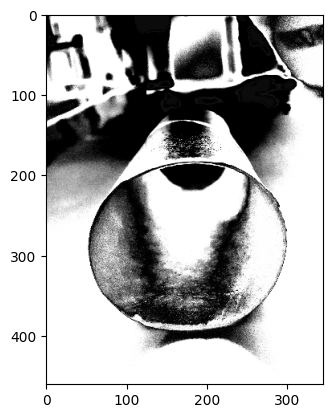

In [90]:
path = r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\cylindre_blanc_2.png"
path = r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\cylindre_NB.jpeg"
img = plt.imread(path)
img = cv2.resize(img, None, fx=0.1, fy=0.1)
plt.imshow(img)
img.shape

In [91]:
h, w, channels = img.shape
pixels = img.reshape(-1, channels)
coordinates = np.column_stack([np.repeat(np.arange(w), h), np.tile(np.arange(h), w)])

In [92]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(pixels)
labels = kmeans.labels_
Counter(labels)


Counter({np.int32(0): 99565, np.int32(1): 59941})

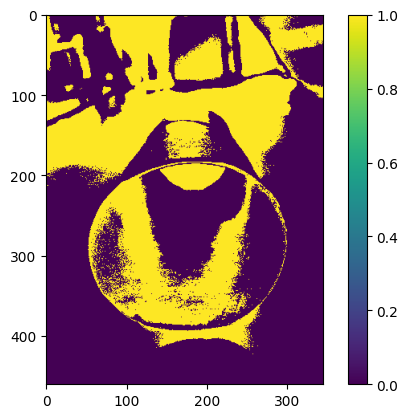

In [93]:
labels_img = labels.reshape(img.shape[0], img.shape[1])
plt.imshow(labels_img)
plt.colorbar()
plt.show()

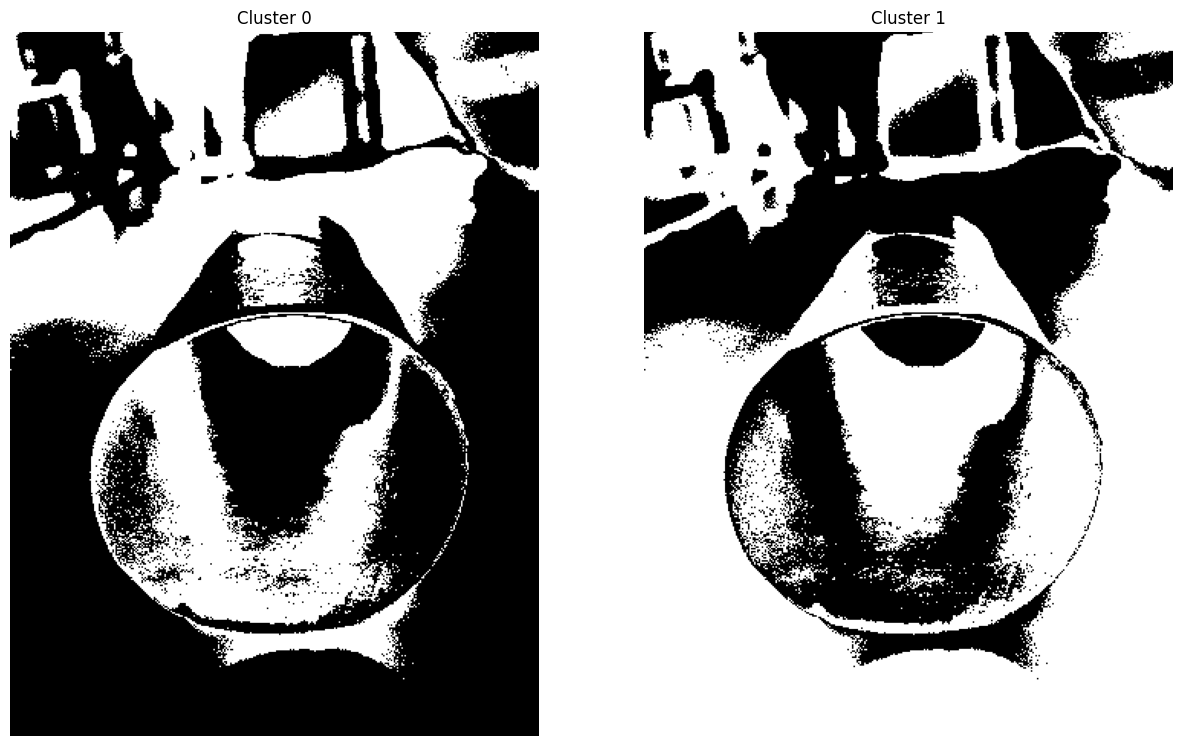

In [94]:
# Visualisons chaque cluster séparément
fig, ax = plt.subplots(len(set(labels))//2, 2, figsize=(15, 15))
ax = ax.flatten()
for i in range(len(set(labels))):
    mask = (labels_img == i)
    cluster_img = np.full_like(img, 255)
    cluster_img[mask] = [0, 0, 0] #sample(list(np.linspace(0, 1 ,100)), 3) + [1]  # Rouge (RGB)
    #cluster_img[mask] = img[mask]
    ax[i].imshow(cluster_img)
    ax[i].set_title(f"Cluster {i}")
    ax[i].axis('off')


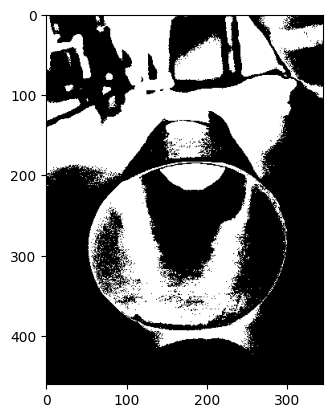

(461, 346, 3)

In [95]:
# Un masque pour le cluster
mask = np.isin(labels_img, [0])
# Un masque pour une image vide
cluster_img = np.full_like(img, 255)
# Superposition du masque du cluster sur le masque de l'image vide
cluster_img[mask] = [0, 0, 0] #sample(list(np.linspace(0, 1 ,100)), 3) + [1] # Blanc (RGBA)
# Visualisation
plt.imshow(cluster_img)
plt.show()
cluster_img.shape


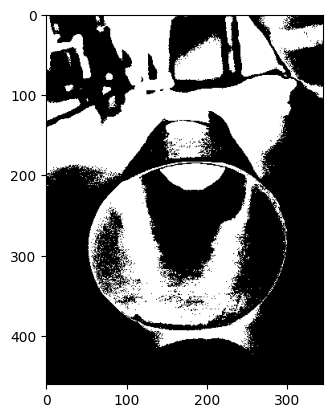

In [98]:
# le cluster 12 apportent le complément à cette image mais il faut séparer spatialement la partie intéressante du reste de l'image
mask = np.isin(labels_img, [1])
cluster_img_comp = np.full_like(img, 0)
cluster_img_comp[mask] = [255, 255, 255] #sample(list(np.linspace(0, 255 ,100)), 3)
plt.imshow(cluster_img_comp)

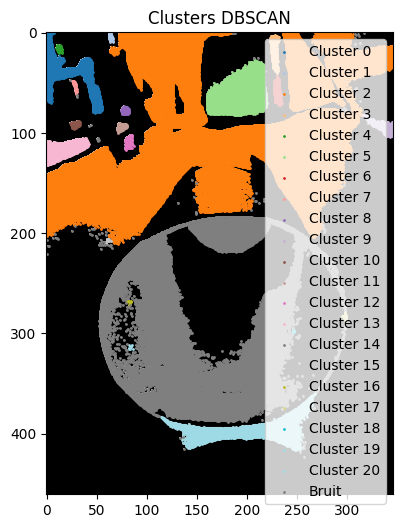

Counter({np.int64(2): 32468,
         np.int64(14): 19426,
         np.int64(5): 2334,
         np.int64(20): 2272,
         np.int64(0): 1336,
         np.int64(13): 678,
         np.int64(-1): 357,
         np.int64(9): 244,
         np.int64(3): 232,
         np.int64(6): 160,
         np.int64(12): 86,
         np.int64(11): 73,
         np.int64(8): 62,
         np.int64(10): 61,
         np.int64(4): 40,
         np.int64(1): 33,
         np.int64(7): 30,
         np.int64(17): 15,
         np.int64(15): 10,
         np.int64(19): 9,
         np.int64(16): 8,
         np.int64(18): 7})

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Extraire les coordonnées des points non-noirs
points = np.argwhere(cluster_img_comp[:, :, :2].sum(axis=2) > 0)

# 2. Appliquer DBSCAN
dbscan = DBSCAN(eps=3, min_samples=9)
labels_dbscan = dbscan.fit_predict(points)

# 3. Visualiser
plt.figure(figsize=(10, 6))
plt.imshow(cluster_img_comp)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

for i, color in enumerate(colors):
    mask = (labels_dbscan == i)
    plt.scatter(points[mask, 1], points[mask, 0], color=color, s=1, label=f'Cluster {i}')

if -1 in labels_dbscan:
    mask = (labels_dbscan == -1)
    plt.scatter(points[mask, 1], points[mask, 0], color='gray', s=1, label='Bruit')

plt.legend()
plt.title("Clusters DBSCAN")
plt.show()
set(labels_dbscan)
Counter(labels_dbscan)

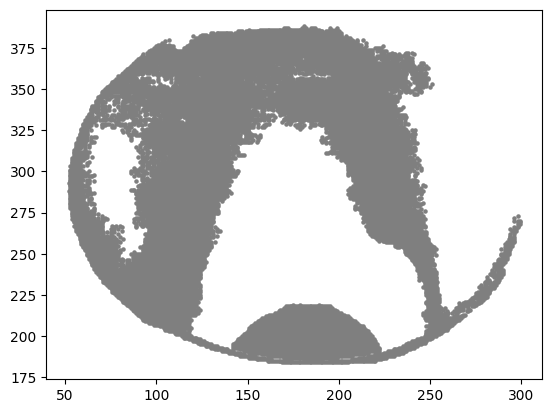

In [100]:
# Visualiser uniquement le cluster 6
for i in [14]:
    mask = (labels_dbscan == i)
    plt.scatter(points[mask, 1], points[mask, 0], color=colors[i], s=5, label=f'Cluster {i}')

In [101]:
# On extrait les coordonnées des points du cluster 6
mask = np.where(np.isin(labels_dbscan, [14]))
labels_dbscan_coords_1 = [[i, j] for i, j in zip(points[mask, 0], points[mask, 1])]
labels_dbscan_coords_1 = np.array(labels_dbscan_coords_1)
labels_dbscan_coords_1 = labels_dbscan_coords_1.T[:,:,-1]
print(labels_dbscan_coords_1)


[[184 169]
 [184 170]
 [184 171]
 ...
 [387 195]
 [387 199]
 [388 181]]


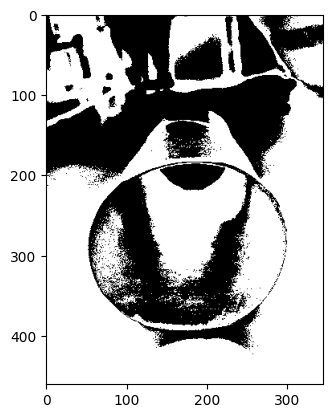

In [103]:
# le cluster 12 apportent le complément à cette image mais il faut séparer spatialement la partie intéressante du reste de l'image
mask = np.isin(labels_img, [0])
cluster_img_comp = np.full_like(img, 0)
cluster_img_comp[mask] = [255, 255, 255] #sample(list(np.linspace(0, 255 ,100)), 3)
plt.imshow(cluster_img_comp)

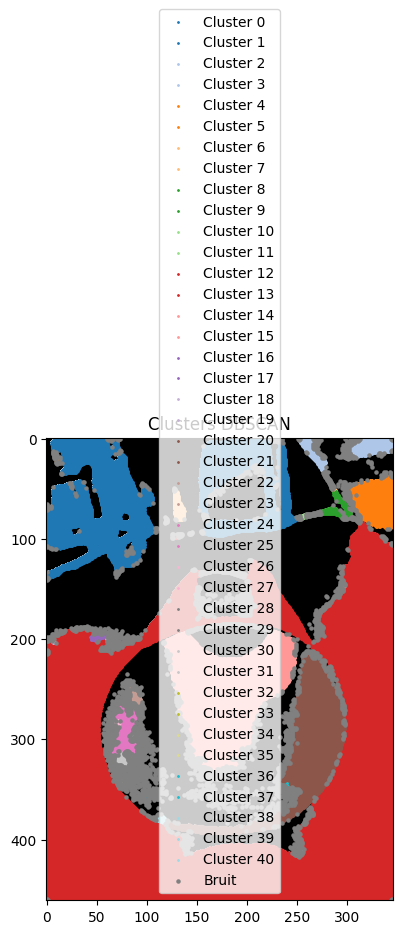

Counter({np.int64(12): 57785,
         np.int64(15): 10691,
         np.int64(0): 9142,
         np.int64(21): 6861,
         np.int64(1): 5169,
         np.int64(-1): 5116,
         np.int64(5): 1726,
         np.int64(25): 755,
         np.int64(3): 609,
         np.int64(2): 331,
         np.int64(7): 240,
         np.int64(8): 165,
         np.int64(9): 146,
         np.int64(23): 142,
         np.int64(31): 140,
         np.int64(38): 73,
         np.int64(16): 69,
         np.int64(24): 42,
         np.int64(17): 26,
         np.int64(13): 23,
         np.int64(27): 23,
         np.int64(28): 21,
         np.int64(22): 18,
         np.int64(26): 18,
         np.int64(30): 18,
         np.int64(32): 18,
         np.int64(39): 16,
         np.int64(4): 13,
         np.int64(6): 13,
         np.int64(10): 13,
         np.int64(14): 13,
         np.int64(18): 13,
         np.int64(20): 13,
         np.int64(33): 13,
         np.int64(34): 13,
         np.int64(35): 13,
         np.in

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Extraire les coordonnées des points non-noirs
points = np.argwhere(cluster_img_comp[:, :, :2].sum(axis=2) > 0)

# 2. Appliquer DBSCAN
dbscan = DBSCAN(eps=2, min_samples=13)
labels_dbscan = dbscan.fit_predict(points)

# 3. Visualiser
plt.figure(figsize=(10, 6))
plt.imshow(cluster_img_comp)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

for i, color in enumerate(colors):
    mask = (labels_dbscan == i)
    plt.scatter(points[mask, 1], points[mask, 0], color=color, s=1, label=f'Cluster {i}')

if -1 in labels_dbscan:
    mask = (labels_dbscan == -1)
    plt.scatter(points[mask, 1], points[mask, 0], color='gray', s=5, label='Bruit')

plt.legend()
plt.title("Clusters DBSCAN")
plt.show()
set(labels_dbscan)
Counter(labels_dbscan)

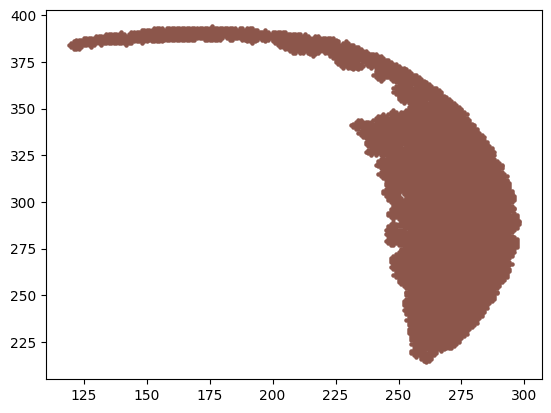

In [105]:
# Visualiser uniquement le cluster 6
for i in [21]:
    mask = (labels_dbscan == i)
    plt.scatter(points[mask, 1], points[mask, 0], color=colors[i], s=5, label=f'Cluster {i}')

In [106]:
# On extrait les coordonnées des points du cluster 6
mask = np.where(np.isin(labels_dbscan, [21]))
labels_dbscan_coords_2 = [[i, j] for i, j in zip(points[mask, 0], points[mask, 1])]
labels_dbscan_coords_2 = np.array(labels_dbscan_coords_2)
labels_dbscan_coords_2 = labels_dbscan_coords_2.T[:,:,-1]
print(labels_dbscan_coords_2)

[[214 261]
 [215 260]
 [215 261]
 ...
 [393 191]
 [393 192]
 [394 176]]


In [107]:
# On rajoute à cluster_img les points du cluster 6
result_img = np.full_like(img, 255)    
for i,j in (np.vstack((labels_dbscan_coords_1, labels_dbscan_coords_2))):
    result_img[i,  j, :] = [0, 0, 0]  # Rouge (RGB)

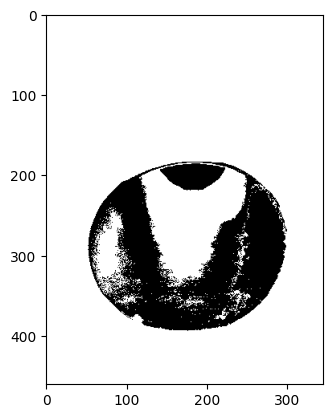

In [108]:
plt.imshow(result_img)

In [113]:
contour = []
for line in range(result_img.shape[0]):
    try:
        ind_min = np.min(np.where(np.all(result_img[line] == [0, 0, 0], axis=1)))
        ind_max = np.max(np.where(np.all(result_img[line] == [0, 0, 0], axis=1)))
        contour.append([line, ind_min])
        contour.append([line, ind_max])
    except:
        pass
contour = np.array(contour)

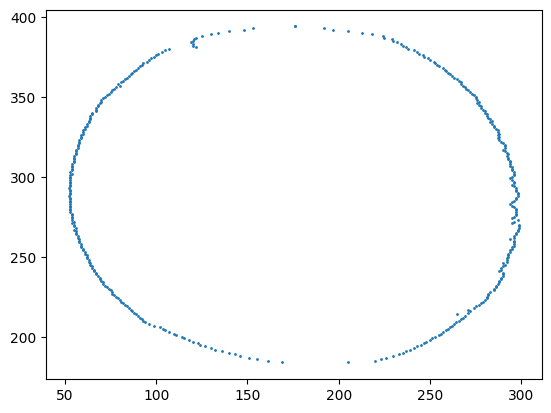

In [114]:
plt.scatter(contour[:,1], contour[:,0], s=1)


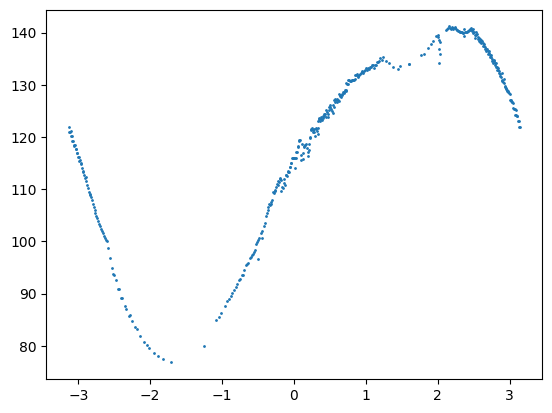

In [119]:
O = np.array([180, 260])
rho = [np.sqrt((x-O[1])**2 + (y-O[0])**2) for x,y in contour]
phi = [np.arctan2(x-O[1], y-O[0]) for x,y in contour]
plt.scatter(phi, rho, s=1)

In [167]:
#specify degree of 3 for polynomial regression model
#include bias=False means don't force y-intercept to equal zero
poly = PolynomialFeatures(degree=10, include_bias=False)

#reshape data to work properly with sklearn
poly_features = poly.fit_transform(np.array(phi).reshape(-1, 1))

#fit polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, rho)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


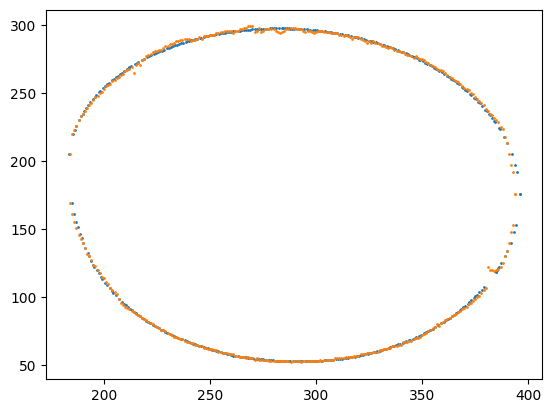

In [168]:
rho_pred = poly_reg_model.predict(poly_features)
y = (rho_pred) * np.cos(phi) + O[0]
x = (rho_pred) * np.sin(phi) + O[1]
plt.scatter(x, y, s=1)
plt.scatter(contour[:,0], contour[:,1], s=1)

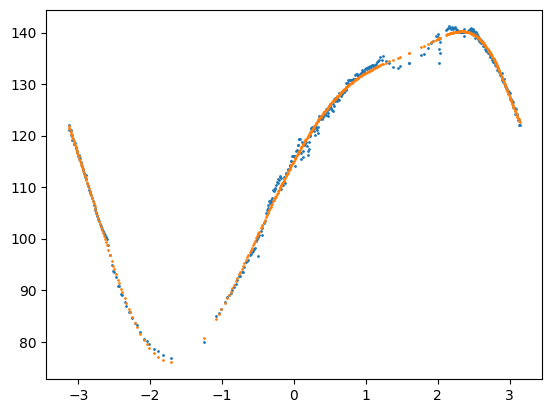

In [169]:
plt.scatter(phi, rho, s=1)
plt.scatter(phi, rho_pred, s=1)

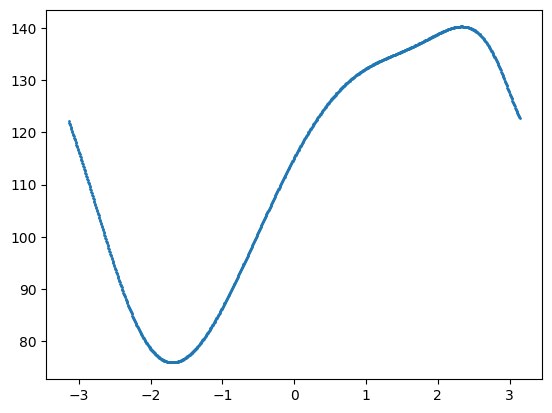

In [170]:
phi_ = np.linspace(-np.pi, np.pi, 1000)
phi_poly_ = poly.transform(phi_.reshape(-1, 1))
rho_poly_ = poly_reg_model.predict(phi_poly_)
plt.scatter(phi_, rho_poly_, s=1)



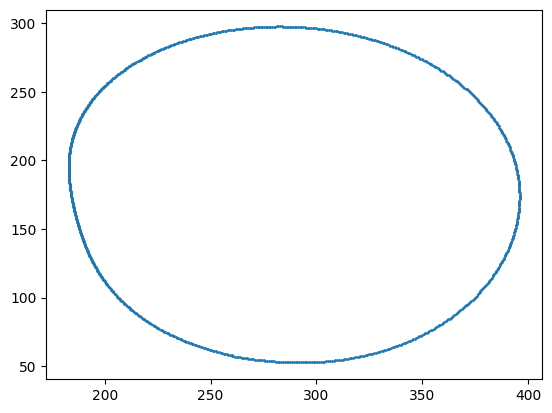

In [171]:
y_ = (rho_poly_) * np.cos(phi_) + O[0]
x_ = (rho_poly_) * np.sin(phi_) + O[1]
plt.scatter(x_, y_, s=1)